<a href="https://colab.research.google.com/github/maheswarids/hdb-resale-analysis/blob/main/HBD_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Importing the dataset**


In [34]:
import pandas as pd

df = pd.read_csv('/content/data.csv')

# **Basic Data Exploration**

In [35]:
df.head()

,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,resale_price
0,2015-01,ANG MO KIO,3 ROOM,174,ANG MO KIO AVE 4,07 TO 09,60.0,Improved,1986,70,255000.0
1,2015-01,ANG MO KIO,3 ROOM,541,ANG MO KIO AVE 10,01 TO 03,68.0,New Generation,1981,65,275000.0
2,2015-01,ANG MO KIO,3 ROOM,163,ANG MO KIO AVE 4,01 TO 03,69.0,New Generation,1980,64,285000.0
3,2015-01,ANG MO KIO,3 ROOM,446,ANG MO KIO AVE 10,01 TO 03,68.0,New Generation,1979,63,290000.0
4,2015-01,ANG MO KIO,3 ROOM,557,ANG MO KIO AVE 10,07 TO 09,68.0,New Generation,1980,64,290000.0


In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37153 entries, 0 to 37152
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   month                37153 non-null  object 
 1   town                 37153 non-null  object 
 2   flat_type            37153 non-null  object 
 3   block                37153 non-null  object 
 4   street_name          37153 non-null  object 
 5   storey_range         37153 non-null  object 
 6   floor_area_sqm       37153 non-null  float64
 7   flat_model           37153 non-null  object 
 8   lease_commence_date  37153 non-null  int64  
 9   remaining_lease      37153 non-null  int64  
 10  resale_price         37153 non-null  float64
dtypes: float64(2), int64(2), object(7)
memory usage: 3.1+ MB


In [37]:
df.describe()

,floor_area_sqm,lease_commence_date,remaining_lease,resale_price
count,37153.000000,37153.000000,37153.000000,3.715300e+04
mean,97.020386,1990.920195,73.913116,4.368628e+05
std,24.198360,10.862330,10.885456,1.358052e+05
min,31.000000,1966.000000,48.000000,1.900000e+05
25%,74.000000,1984.000000,66.000000,3.400000e+05
50%,96.000000,1989.000000,72.000000,4.080000e+05
75%,111.000000,2000.000000,83.000000,4.950000e+05
max,280.000000,2013.000000,97.000000,1.150000e+06


# **Data Cleaning**

**Checking for missing values**

In [38]:
df.isnull().sum()

,0
month,0
town,0
flat_type,0
block,0
street_name,0
storey_range,0
floor_area_sqm,0
flat_model,0
lease_commence_date,0
remaining_lease,0


***Checking for duplicate values***

In [39]:
df.duplicated().sum()

np.int64(24)

In [40]:
df[df.duplicated()]

,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,resale_price
661,2015-01,KALLANG/WHAMPOA,3 ROOM,57,GEYLANG BAHRU,16 TO 18,65.0,Improved,1974,58,315000.0
2166,2015-02,TAMPINES,3 ROOM,403,TAMPINES ST 41,07 TO 09,69.0,Improved,1985,69,350000.0
3896,2015-04,BEDOK,4 ROOM,701,BEDOK RESERVOIR RD,10 TO 12,93.0,New Generation,1980,64,400000.0
4246,2015-04,CLEMENTI,3 ROOM,714,CLEMENTI WEST ST 2,10 TO 12,67.0,New Generation,1980,64,300000.0
5493,2015-05,BEDOK,3 ROOM,409,BEDOK NTH AVE 2,07 TO 09,68.0,New Generation,1980,63,340000.0
6076,2015-05,JURONG WEST,3 ROOM,501,JURONG WEST ST 51,01 TO 03,74.0,Model A,1986,69,304000.0
7091,2015-06,BEDOK,3 ROOM,410,BEDOK NTH AVE 2,04 TO 06,68.0,New Generation,1980,63,340000.0
7182,2015-06,BISHAN,4 ROOM,267,BISHAN ST 24,04 TO 06,104.0,Model A,1992,76,530000.0
9114,2015-07,CHOA CHU KANG,5 ROOM,690D,CHOA CHU KANG CRES,13 TO 15,110.0,Improved,2003,87,390000.0
10215,2015-08,ANG MO KIO,3 ROOM,473,ANG MO KIO AVE 10,07 TO 09,67.0,New Generation,1984,67,308000.0


**Standardizing Text Data**

In [41]:
df['town'] = df['town'].str.strip().str.title()
df['flat_type'] = df['flat_type'].str.strip().str.upper()
df['street_name'] = df['street_name'].str.strip().str.title()
df['flat_model'] = df['flat_model'].str.strip().str.title()

**Validate and Convert Data Types**

In [42]:
df['month'] = pd.to_datetime(df['month'], format = '%Y-%m')

In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37153 entries, 0 to 37152
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   month                37153 non-null  datetime64[ns]
 1   town                 37153 non-null  object        
 2   flat_type            37153 non-null  object        
 3   block                37153 non-null  object        
 4   street_name          37153 non-null  object        
 5   storey_range         37153 non-null  object        
 6   floor_area_sqm       37153 non-null  float64       
 7   flat_model           37153 non-null  object        
 8   lease_commence_date  37153 non-null  int64         
 9   remaining_lease      37153 non-null  int64         
 10  resale_price         37153 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(2), object(6)
memory usage: 3.1+ MB


# **Feature Engineering**

In [44]:
df['year'] = df['month'].dt.year

In [45]:
df['month_num'] = df['month'].dt.month

In [46]:
df['month_name'] = df['month'].dt.month_name()

In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37153 entries, 0 to 37152
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   month                37153 non-null  datetime64[ns]
 1   town                 37153 non-null  object        
 2   flat_type            37153 non-null  object        
 3   block                37153 non-null  object        
 4   street_name          37153 non-null  object        
 5   storey_range         37153 non-null  object        
 6   floor_area_sqm       37153 non-null  float64       
 7   flat_model           37153 non-null  object        
 8   lease_commence_date  37153 non-null  int64         
 9   remaining_lease      37153 non-null  int64         
 10  resale_price         37153 non-null  float64       
 11  year                 37153 non-null  int32         
 12  month_num            37153 non-null  int32         
 13  month_name           37153 non-

In [48]:
df.head()

,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,resale_price,year,month_num,month_name
0,2015-01-01,Ang Mo Kio,3 ROOM,174,Ang Mo Kio Ave 4,07 TO 09,60.0,Improved,1986,70,255000.0,2015,1,January
1,2015-01-01,Ang Mo Kio,3 ROOM,541,Ang Mo Kio Ave 10,01 TO 03,68.0,New Generation,1981,65,275000.0,2015,1,January
2,2015-01-01,Ang Mo Kio,3 ROOM,163,Ang Mo Kio Ave 4,01 TO 03,69.0,New Generation,1980,64,285000.0,2015,1,January
3,2015-01-01,Ang Mo Kio,3 ROOM,446,Ang Mo Kio Ave 10,01 TO 03,68.0,New Generation,1979,63,290000.0,2015,1,January
4,2015-01-01,Ang Mo Kio,3 ROOM,557,Ang Mo Kio Ave 10,07 TO 09,68.0,New Generation,1980,64,290000.0,2015,1,January


# **Analysis and Visualization**

**Categorial Analysis**

**Analyze Flat Types**

In [49]:
df['flat_type'].value_counts()

,count
flat_type,
4 ROOM,15190
3 ROOM,10021
5 ROOM,8735
EXECUTIVE,2840
2 ROOM,348
1 ROOM,14
MULTI-GENERATION,5


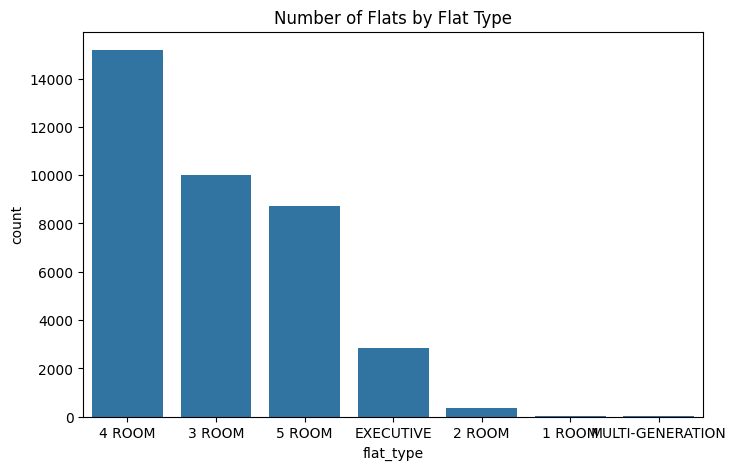

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.countplot(data=df, x='flat_type', order=df['flat_type'].value_counts().index)
plt.title('Number of Flats by Flat Type')
plt.show()

**Analyze Towns**

In [51]:
df['town'].value_counts()

,count
town,
Jurong West,2888
Tampines,2666
Sengkang,2619
Woodlands,2599
Bedok,2442
Yishun,2154
Hougang,1909
Ang Mo Kio,1851
Choa Chu Kang,1770


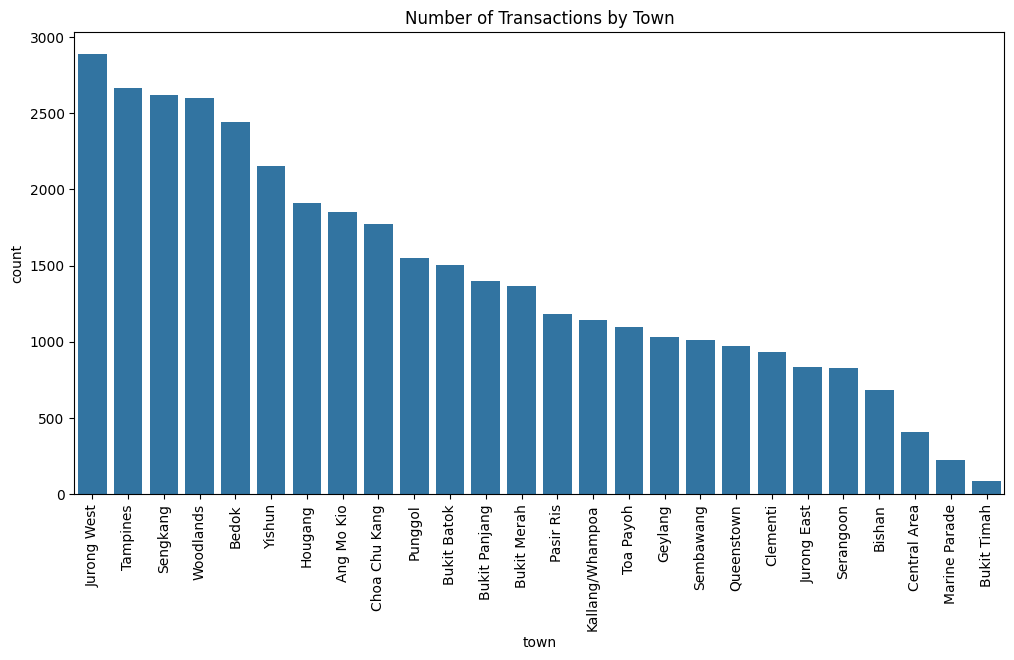

In [52]:
plt.figure(figsize=(12,6))
sns.countplot(data=df, x='town', order=df['town'].value_counts().index)
plt.xticks(rotation=90)
plt.title('Number of Transactions by Town')
plt.show()

**Numerical Aggregation**

**Average Resale price by Town**

In [53]:
avg_price_town = df.groupby('town')['resale_price'].mean().sort_values(ascending=False)
avg_price_town

,resale_price
town,
Bukit Timah,709368.909091
Central Area,673756.302439
Bishan,602681.998365
Marine Parade,547957.013333
Bukit Merah,540764.565568
Queenstown,536859.534501
Kallang/Whampoa,496018.706445
Pasir Ris,477060.805063
Serangoon,474866.234867


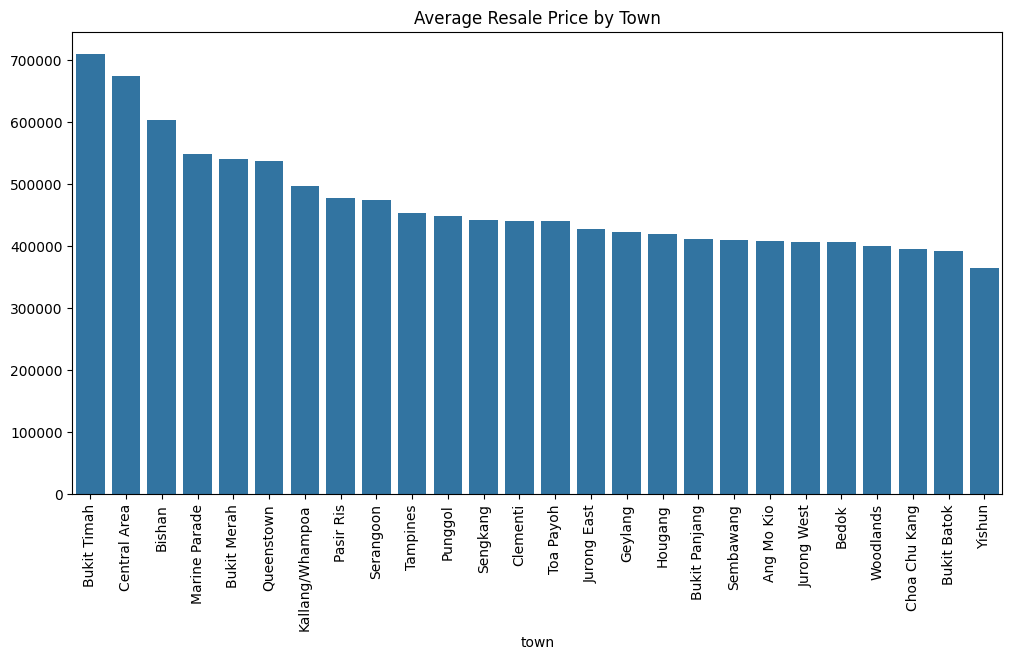

In [54]:
plt.figure(figsize=(12,6))
sns.barplot(x = avg_price_town.index, y = avg_price_town.values)
plt.xticks(rotation=90)
plt.title('Average Resale Price by Town')
plt.show()

**Average Resale price by Flat Type**

In [55]:
avg_price_flat = df.groupby('flat_type')['resale_price'].mean().sort_values(ascending=False)
avg_price_flat

,resale_price
flat_type,
MULTI-GENERATION,739200.000000
EXECUTIVE,622444.270380
5 ROOM,519054.873571
4 ROOM,434078.502873
3 ROOM,323611.247756
2 ROOM,246794.195402
1 ROOM,209714.285714


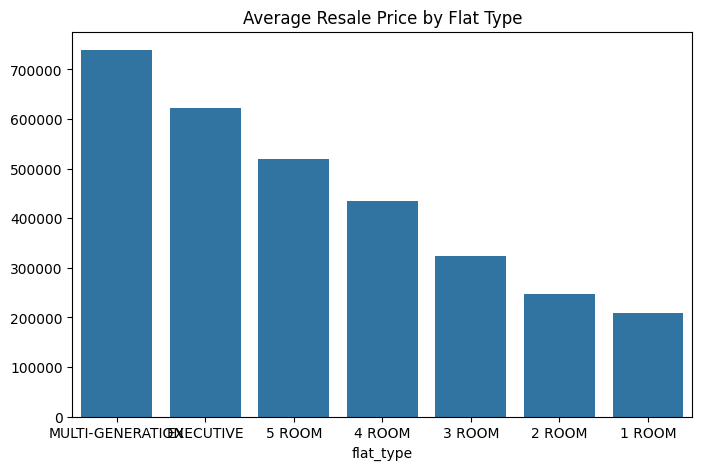

In [56]:
plt.figure(figsize=(8,5))
sns.barplot(x=avg_price_flat.index, y=avg_price_flat.values)
plt.title('Average Resale Price by Flat Type')
plt.show()

**Time-based Analysis**

**Resale price trend by Year**

In [57]:
avg_price_year = df.groupby('year')['resale_price'].mean()
avg_price_year

,resale_price
year,
2015,434709.557960
2016,438838.964559


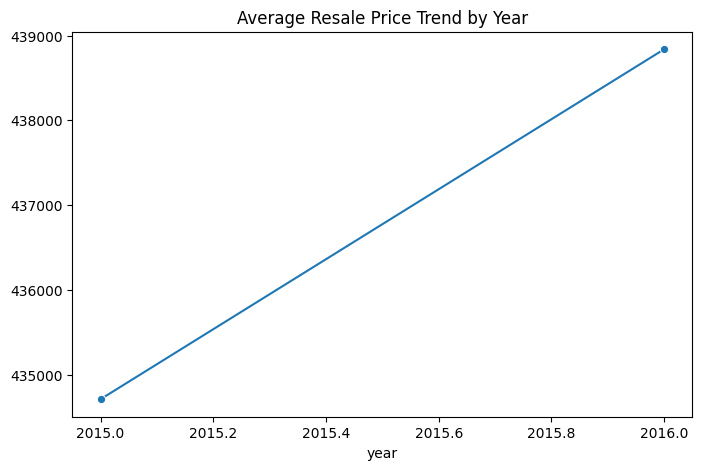

In [58]:
plt.figure(figsize=(8,5))
sns.lineplot(x=avg_price_year.index, y=avg_price_year.values, marker='o')
plt.title('Average Resale Price Trend by Year')
plt.show()

**Average Resale price by Month**

In [59]:
avg_price_month = df.groupby('month_num')['resale_price'].mean()
avg_price_month

,resale_price
month_num,
1,436190.159636
2,437482.645257
3,435367.521146
4,434290.586532
5,441586.930212
6,434378.493631
7,436658.926033
8,436509.631342
9,439554.311396


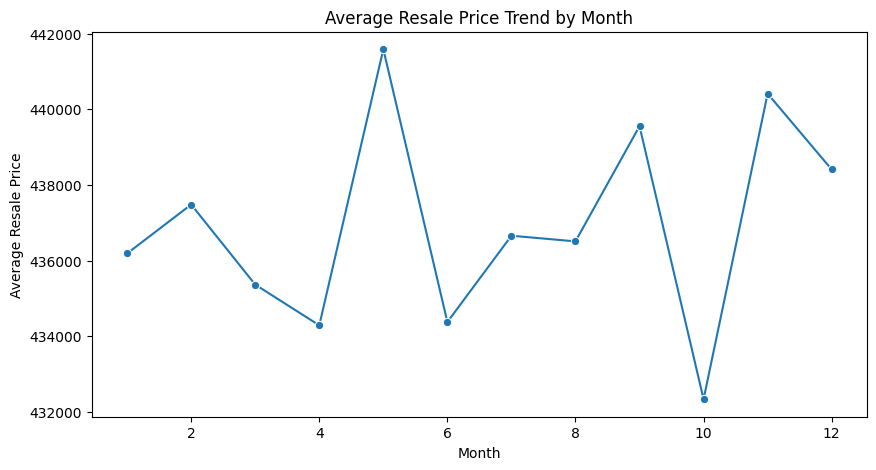

In [60]:
plt.figure(figsize=(10,5))
sns.lineplot(x=avg_price_month.index, y=avg_price_month.values, marker='o')
plt.title('Average Resale Price Trend by Month')
plt.xlabel('Month')
plt.ylabel('Average Resale Price')
plt.show()

# **Extracting the cleaned Dataset**

In [61]:
df.to_csv('hdb_resale_cleaned.csv', index=False)